In [ ]:
# ------------------------------------
# TAHAP 1: INSTALASI & IMPORT LIBRARY
# ------------------------------------
print("Menginstal library...")
# Instalasi untuk VADER (Lexicon), TextBlob (Lexicon), dan KaggleHub
!pip install vaderSentiment textblob kagglehub -q

import kagglehub
import pandas as pd
import os
import zipfile
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

print("Instalasi dan import selesai.")

Menginstal library...


In [ ]:
# ------------------------------------
# TAHAP 2 (PERBAIKAN): UNDUH DATASET
# ------------------------------------
print("Mengunduh dataset dari Kaggle...")

# Kode ini mengunduh dan otomatis mengekstrak data
path = kagglehub.dataset_download("ekaprasetyaningrum/mental-health-sentiment-analysis-dataset")

print(f"\nDataset telah diunduh dan diekstrak ke folder:")
print(path)

# Tampilkan isi folder agar kita tahu nama file CSV-nya
print("\nIsi folder dataset:")
print(os.listdir(path))

In [ ]:
# ------------------------------------
# TAHAP 3 (PERBAIKAN): LOAD & CEK DATA
# ------------------------------------

# 'path' adalah variabel dari sel sebelumnya (Tahap 2)
# GANTI 'mental-health.csv' jika output Tahap 2 menunjukkan nama file yang berbeda
file_name = 'mental-health.csv'

# Menggabungkan path folder dari Tahap 2 dengan nama file
file_path = os.path.join(path, file_name)

try:
    df = pd.read_csv(file_path)
    print(f"Dataset '{file_name}' berhasil di-load.")

    # Asumsi nama kolom adalah 'text' dan 'sentiment'
    df = df[['text', 'sentiment']].dropna()
    df['text'] = df['text'].astype(str)

    print("\nData (5 baris pertama):")
    print(df.head())

except Exception as e:
    print(f"Gagal me-load CSV. Pastikan nama file '{file_name}' sudah benar.")
    print(f"Error: {e}")

Library berhasil diimpor.

--- LANGKAH 1: MEMUAT DATA & ANALISIS DESKRIPTIF ---
5 Data Teratas:
                                                Text Sentimen
0  gw kayanya udh burnout bgt ini 3 minggu dihaja...  Negatif
1  punya dosen gini amat ya untung selalu bantuin...  Negatif
2  So burnout karena harus maintain kerjaan menta...  Negatif
3  Ini genshin kapan munculin fitur skip dah. Uda...  Negatif
4  Pengen update tapi ternyata w masih lemes. w h...  Negatif

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2903 entries, 0 to 2902
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      2903 non-null   object
 1   Sentimen  2902 non-null   object
dtypes: object(2)
memory usage: 45.5+ KB

Distribusi Kelas (Sentimen):
Sentimen
Positif    1515
Negatif    1387
Name: count, dtype: int64

--- LANGKAH 2: EKSPLORASI DATA (EDA) ---


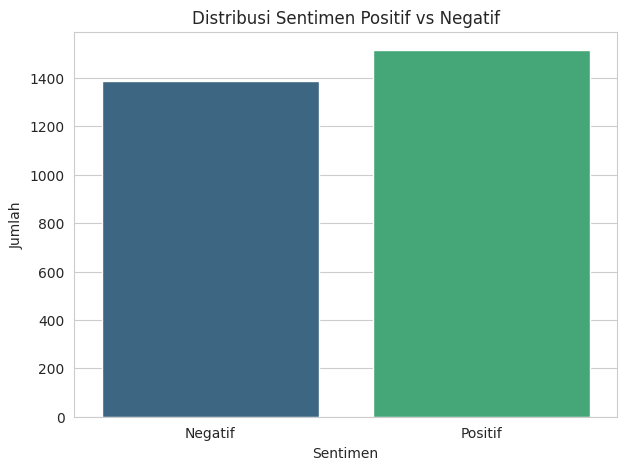

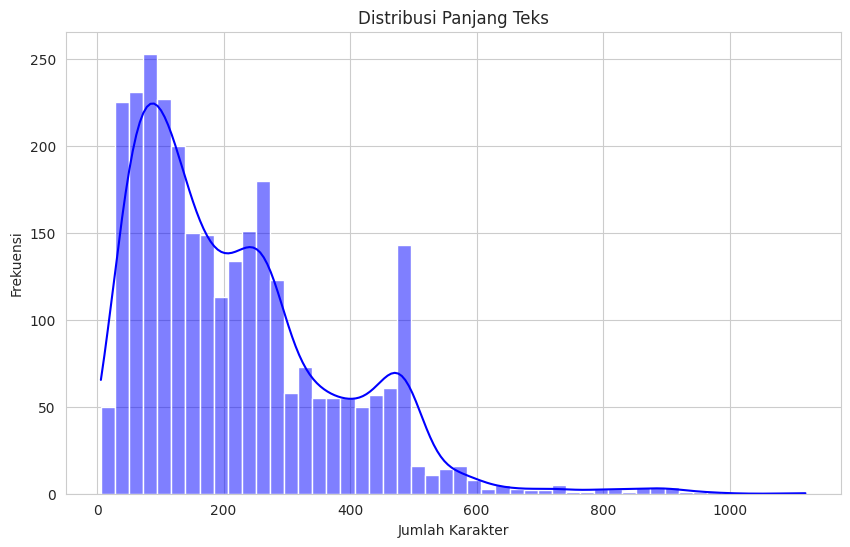

count    2903.000000
mean      217.474681
std       157.466282
min         6.000000
25%        93.000000
50%       179.000000
75%       293.000000
max      1120.000000
Name: panjang_teks, dtype: float64

--- LANGKAH 3: PRA-PEMROSESAN DATA ---
Jumlah data sebelum dropna: 2903
Jumlah data setelah dropna: 2902
Jumlah data sebelum drop_duplicates: 2902
Jumlah data setelah drop_duplicates: 2902

Label Encoding:
Sentimen  label
Positif   1        1515
Negatif   0        1387
Name: count, dtype: int64

Ukuran Data Training: 2321
Ukuran Data Testing: 581

--- LANGKAH 4: EKSTRAKSI FITUR (INDOBERT) ---
Proses ini mungkin memakan waktu beberapa menit...
Menggunakan GPU (device=0)


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Memulai ekstraksi fitur data training...
Memulai ekstraksi fitur data testing...

Ekstraksi Fitur Selesai.
Bentuk (shape) fitur training: (2321, 768)
Bentuk (shape) fitur testing: (581, 768)

--- LANGKAH 5: MODELING & EVALUASI ---

--- Melatih Model: Logistic Regression ---
Laporan Klasifikasi untuk Logistic Regression:
              precision    recall  f1-score   support

     Negatif       0.79      0.81      0.80       278
     Positif       0.82      0.80      0.81       303

    accuracy                           0.80       581
   macro avg       0.80      0.80      0.80       581
weighted avg       0.80      0.80      0.80       581


--- Melatih Model: K-Nearest Neighbors ---
Laporan Klasifikasi untuk K-Nearest Neighbors:
              precision    recall  f1-score   support

     Negatif       0.77      0.78      0.77       278
     Positif       0.79      0.78      0.79       303

    accuracy                           0.78       581
   macro avg       0.78      0.78      0.7

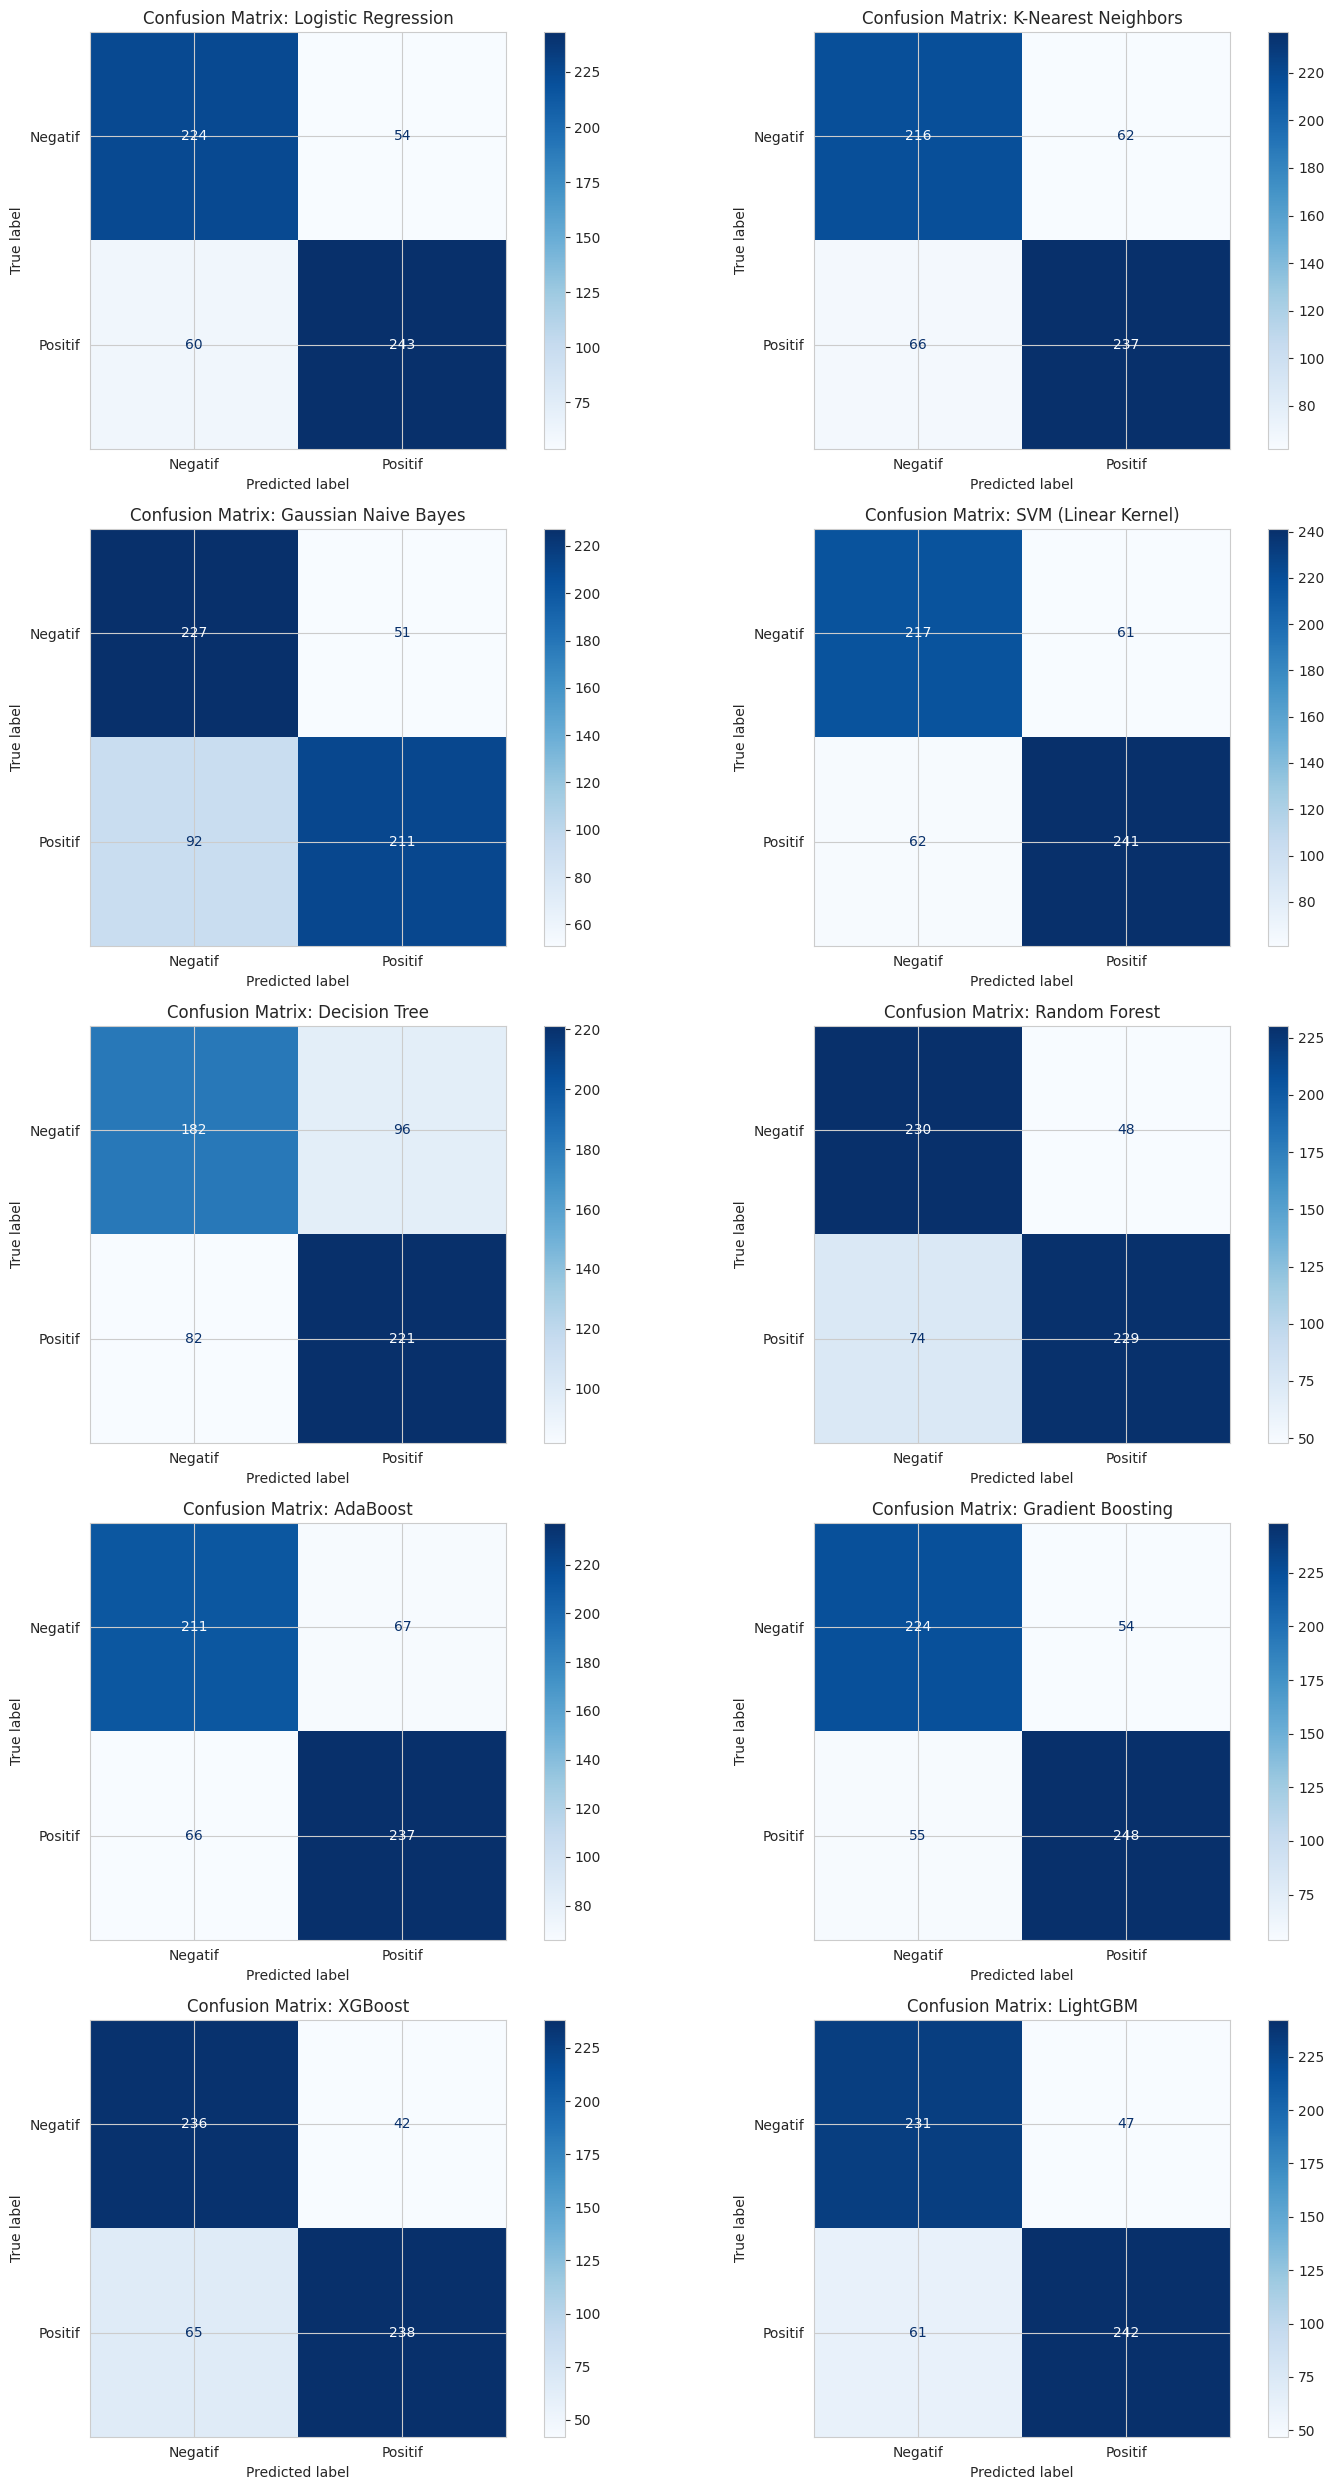


Membuat tabel perbandingan model...

Tabel Perbandingan Model (Diurutkan berdasarkan F1-Score):
|                      |   Accuracy |   Precision |   Recall |   F1-Score |
|:---------------------|-----------:|------------:|---------:|-----------:|
| XGBoost              |     0.8158 |      0.8184 |   0.8158 |     0.8159 |
| LightGBM             |     0.8141 |      0.8152 |   0.8141 |     0.8142 |
| Gradient Boosting    |     0.8124 |      0.8124 |   0.8124 |     0.8124 |
| Logistic Regression  |     0.8038 |      0.8041 |   0.8038 |     0.8039 |
| Random Forest        |     0.7900 |      0.7932 |   0.7900 |     0.7900 |
| SVM (Linear Kernel)  |     0.7883 |      0.7883 |   0.7883 |     0.7883 |
| K-Nearest Neighbors  |     0.7797 |      0.7799 |   0.7797 |     0.7797 |
| AdaBoost             |     0.7711 |      0.7711 |   0.7711 |     0.7711 |
| Gaussian Naive Bayes |     0.7539 |      0.7605 |   0.7539 |     0.7534 |
| Decision Tree        |     0.6936 |      0.6934 |   0.6936 |     

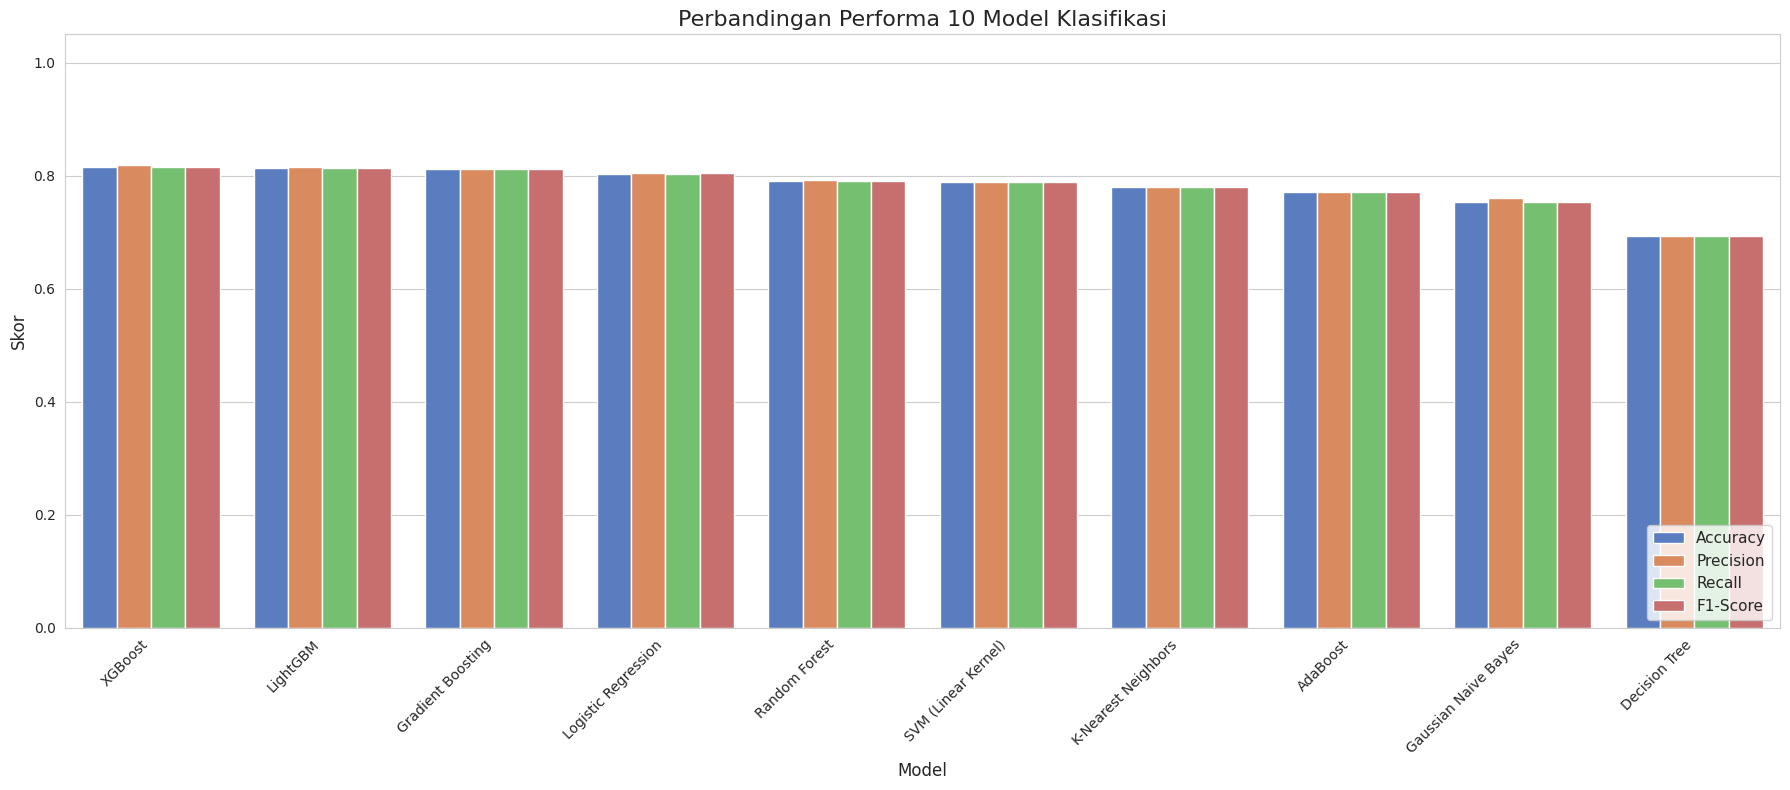


--- Selesai ---


In [6]:
# #################################################################
# #
# # TUGAS ANALISIS SENTIMEN KESEHATAN MENTAL
# #
# # Dataset: Mental Health Sentiment Analysis Dataset.csv
# # Metode: Ekstraksi Fitur Semantik (IndoBERT)
# # Model: 10 Model Klasifikasi Machine Learning
# #
# #################################################################

# ---------------------------------------------------------------
# LANGKAH 0: INSTALASI DAN IMPORT LIBRARY
# ---------------------------------------------------------------
# Jalankan ini di sel pertama jika menggunakan Colab/Jupyter
# !pip install pandas numpy matplotlib seaborn scikit-learn torch transformers xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
from tqdm.auto import tqdm  # Untuk progress bar

# Pra-pemrosesan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ekstraksi Fitur (BERT)
from transformers import pipeline

# Model Klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluasi
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Pengaturan
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("Library berhasil diimpor.")

# ---------------------------------------------------------------
# LANGKAH 1: MEMUAT DATA & ANALISIS DESKRIPTIF
# ---------------------------------------------------------------
print("\n--- LANGKAH 1: MEMUAT DATA & ANALISIS DESKRIPTIF ---")

# Ganti 'path_to_your_file' dengan nama file Anda
# Jika di Colab, upload file dan salin path-nya
file_path = "/content/Mental Health Sentiment Analysis Dataset.csv"

try:
    df = pd.read_csv(file_path, encoding='latin1') # Menambahkan encoding='latin1'
except FileNotFoundError:
    print(f"Error: File '{file_path}' tidak ditemukan.")
    print("Pastikan file sudah di-upload dan path-nya benar.")
    # Keluar dari skrip jika file tidak ada
    exit() # Uncommented this line to prevent NameError


print("5 Data Teratas:")
print(df.head())

print("\nInformasi Dataset:")
df.info()

print("\nDistribusi Kelas (Sentimen):")
print(df["Sentimen"].value_counts())

# ---------------------------------------------------------------
# LANGKAH 2: EKSPLORASI DATA (EDA)
# ---------------------------------------------------------------
print("\n--- LANGKAH 2: EKSPLORASI DATA (EDA) ---")

# Visualisasi Distribusi Sentimen
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sentimen", palette="viridis")
plt.title("Distribusi Sentimen Positif vs Negatif")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()

# Analisis Panjang Teks
df["panjang_teks"] = df["Text"].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df["panjang_teks"], bins=50, kde=True, color="blue")
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()

print(df["panjang_teks"].describe())

# ---------------------------------------------------------------
# LANGKAH 3: PRA-PEMROSESAN DATA
# ---------------------------------------------------------------
print("\n--- LANGKAH 3: PRA-PEMROSESAN DATA ---")

# 1. Menghapus data kosong (jika ada)
print(f"Jumlah data sebelum dropna: {len(df)}")
df.dropna(subset=["Text", "Sentimen"], inplace=True)
print(f"Jumlah data setelah dropna: {len(df)}")

# 2. Menghapus data duplikat
print(f"Jumlah data sebelum drop_duplicates: {len(df)}")
df.drop_duplicates(subset=["Text"], inplace=True)
print(f"Jumlah data setelah drop_duplicates: {len(df)}")

# 3. Label Encoding untuk kolom 'Sentimen'
# 'Negatif' -> 0
# 'Positif' -> 1
le = LabelEncoder()
df["label"] = le.fit_transform(df["Sentimen"])
print("\nLabel Encoding:")
print(df[["Sentimen", "label"]].value_counts())
# Menyimpan mapping kelas untuk nanti
target_names = le.classes_

# 4. Split data menjadi Training dan Testing
X = df["Text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nUkuran Data Training: {len(X_train)}")
print(f"Ukuran Data Testing: {len(X_test)}")

# ---------------------------------------------------------------
# LANGKAH 4: EKSTRAKSI FITUR (SEMANTIC - INDOBERT)
# ---------------------------------------------------------------
print("\n--- LANGKAH 4: EKSTRAKSI FITUR (INDOBERT) ---")
print("Proses ini mungkin memakan waktu beberapa menit...")

# Cek ketersediaan GPU (Sangat disarankan di Colab)
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    print("Menggunakan GPU (device=0)")
else:
    print("Menggunakan CPU (device=-1). Proses akan lambat.")

# Muat model IndoBERT untuk feature-extraction
# Kita gunakan pipeline untuk cara termudah
# Model 'indobenchmark/indobert-base-p1'
model_name = "indobenchmark/indobert-base-p1"
feature_extractor = pipeline(
    "feature-extraction", model=model_name, tokenizer=model_name, device=device
)


# Fungsi untuk mendapatkan embedding [CLS] token
# BERT menghasilkan embedding untuk setiap token.
# Kita ambil embedding token [CLS] (token pertama) sebagai representasi seluruh kalimat.
def get_bert_embeddings(texts):
    embeddings = []
    text_list = list(texts)

    # Pipeline akan memproses data dalam batch (lebih cepat)
    # padding=True, truncation=True -> Menangani teks dengan panjang berbeda
    # max_length=512 -> Batas maks token untuk BERT
    # return_tensors='pt' untuk memastikan output konsisten sebagai PyTorch tensors
    outputs = feature_extractor(
        text_list, padding=True, truncation=True, max_length=512, return_tensors='pt'
    )

    # outputs adalah list of tensors, di mana setiap tensor memiliki shape (1, seq_len, hidden_size)
    for output_tensor in outputs:
        # Ambil embedding dari [CLS] token (token pertama dari sequence, pada batch ke-0)
        # Ini akan menghasilkan 1D array (hidden_size,)
        cls_embedding = output_tensor[0, 0, :].cpu().numpy() # Mengambil token CLS
        embeddings.append(cls_embedding)

    return np.array(embeddings)


# Ekstraksi fitur untuk data train dan test
print("Memulai ekstraksi fitur data training...")
X_train_features = get_bert_embeddings(X_train)

print("Memulai ekstraksi fitur data testing...")
X_test_features = get_bert_embeddings(X_test)

print("\nEkstraksi Fitur Selesai.")
print(f"Bentuk (shape) fitur training: {X_train_features.shape}")
print(f"Bentuk (shape) fitur testing: {X_test_features.shape}")

# ---------------------------------------------------------------
# LANGKAH 5: MODELING (10 MODEL KLASIFIKASI)
# ---------------------------------------------------------------
print("\n--- LANGKAH 5: MODELING & EVALUASI ---")

# Daftar 10 model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "SVM (Linear Kernel)": SVC(kernel="linear", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, eval_metric="logloss", random_state=42
    ),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Dictionary untuk menyimpan hasil
results = {}
confusion_matrices = {}

# Looping untuk melatih dan mengevaluasi setiap model
for name, model in models.items():
    print(f"\n--- Melatih Model: {name} ---")

    # 1. Melatih model
    model.fit(X_train_features, y_train)

    # 2. Memprediksi data test
    y_pred = model.predict(X_test_features)

    # 3. Evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # 4. Menyimpan hasil
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    }

    # 5. Menyimpan confusion matrix
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    # 6. Menampilkan Laporan Klasifikasi per Model
    print(f"Laporan Klasifikasi untuk {name}:")
    print(classification_report(y_test, y_pred, target_names=target_names))

# ---------------------------------------------------------------
# LANGKAH 6: VISUALISASI & PERBANDINGAN MODEL
# ---------------------------------------------------------------
print("\n--- LANGKAH 6: VISUALISASI & PERBANDINGAN ---")

# A. VISUALISASI CONFUSION MATRIX (GRID 5x2)
print("Membuat plot Confusion Matrix untuk 10 model...")

fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()  # Ubah jadi array 1D

for i, (name, cm) in enumerate(confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=axes[i], cmap="Blues")
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()


# B. MEMBUAT TABEL PERBANDINGAN MODEL
print("\nMembuat tabel perbandingan model...")

results_df = pd.DataFrame(results).T  # Transpose agar nama model jadi baris
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\nTabel Perbandingan Model (Diurutkan berdasarkan F1-Score):")
print(results_df.to_markdown(floatfmt=".4f"))


# C. MENAMPILKAN 5 MODEL TERBAIK
print("\n--- 5 MODEL TERBAIK ---")
top_5_models = results_df.head(5)
print(top_5_models.to_markdown(floatfmt=".4f"))


# D. VISUALISASI PERBANDINGAN MODEL
print("\nMembuat grafik perbandingan model...")

# Mengubah format dataframe agar mudah di-plot
plot_df = results_df.reset_index().rename(columns={"index": "Model"})
plot_df_melted = plot_df.melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)

plt.figure(figsize=(18, 8))
sns.barplot(
    data=plot_df_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="muted"
)
plt.title("Perbandingan Performa 10 Model Klasifikasi", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Skor", fontsize=12)
plt.ylim(0, 1.05) # Batas y sedikit di atas 1.0
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

print("\n--- Selesai ---")